# fdriver 1단계 시범 분석 v1 (작업 순서 4번)

시범 6개 기업에 대해 다음을 확인한다.

1. `panel()` 한 줄로 매출과 연결 시계열이 분기 한 표로 나오는지, 값마다 발표 시점(available_at)과 등급이 붙는지
2. 실제 panel 에서 `as_of(panel, 날짜)` 가 그 날짜 이후 값을 하나도 포함하지 않는지 (무작위 날짜 10개)
3. 매출 YoY 와 드라이버 YoY 의 상관 (동행, 1분기 선행, 2분기 선행)과 위약 검정
   - (a) 회사와 연결되지 않은 무작위 hs6 30개의 같은 상관 분포에서 실제 드라이버 |상관| 의 백분위
   - (b) 시간 추세만 있는 가짜 시계열(100 + t)과의 상관
4. 동원산업은 2022년 합병 전후를 나눠서도 본다

1단계의 목적은 흐름 검증이다. 상관은 참고용이며 예측력 평가는 2단계에서 한다.
DB 는 읽기만 한다 (이 노트북은 쓰기를 하지 않는다).

In [1]:
import sys, logging, warnings
from pathlib import Path
ROOT = Path.cwd().resolve().parents[2]          # .../investment_strategy
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from DATA.fdriver import asof, db, entity, panel as fp
from DATA.fdriver.adapters import trading_calendar
from DATA.fdriver.pilots import pilot_analysis_v1 as pa

pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30); pd.set_option("display.max_rows", 300)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 차트 색: 기본 검증 팔레트의 범주색 1~3번(고정 순서), 회색 참조 띠, 글자색
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
BAND, INK, INK2, GRID, SURFACE = "#e4e3df", "#0b0b0b", "#52514e", "#e9e8e4", "#fcfcfb"

FIG_DIR = Path.cwd() / "figures_v1"; FIG_DIR.mkdir(exist_ok=True)
OUT_DIR = Path.cwd() / "output_v1"; OUT_DIR.mkdir(exist_ok=True)
PILOTS = entity.PILOTS
WRITES_AT_START = len(db.WRITE_LOG)
print("pilots:", PILOTS)

pilots: {'005930': '삼성전자', '006040': '동원산업', '267270': '현대건설기계', '278470': '에이피알', '003350': '한국화장품제조', '039130': '하나투어'}


## 1. 거래일 달력 (KSE_Price 2026-10-02 갱신 반영)

In [2]:
cal = trading_calendar()      # asof 영업일 계산에도 등록됨
print(f"거래일 {len(cal):,}일, {cal.min().date()} ~ {cal.max().date()}")
info = entity.entity_info(list(PILOTS))[["entity_id", "name_kr", "market", "listed_status", "fiscal_year_end"]]
display(info)

거래일 3,281일, 2013-05-21 ~ 2026-10-02


,entity_id,name_kr,market,listed_status,fiscal_year_end
0,003350,한국화장품제조,KOSPI,listed,12
1,005930,삼성전자,KOSPI,listed,12
2,006040,동원산업,KOSPI,listed,12
3,039130,하나투어,KOSPI,listed,12
4,267270,HD건설기계,KOSPI,listed,12
5,278470,에이피알,KOSPI,listed,12


## 2. panel: 6개 기업 분기 표와 등급 비율

In [3]:
panels = {}
for eid in PILOTS:
    panels[eid] = fp.panel(eid, trade_items=pa.TRADE_ITEMS.get(eid, ("expDlr", "expWgt")))

rows = []
for eid, p in panels.items():
    g = p["asof_quality"].value_counts(normalize=True)
    rev = p[p["driver"] == "revenue"]
    rows.append({"종목": eid, "기업": PILOTS[eid], "행 수": len(p), "시계열 수": p["driver"].nunique(),
                 "매출 분기 수": len(rev), "매출 시작": rev["period_end"].min().date(), "매출 끝": rev["period_end"].max().date(),
                 "A": round(g.get("A", 0), 3), "B": round(g.get("B", 0), 3), "C": round(g.get("C", 0), 3),
                 "available_at 빈 값": int(p["available_at"].isna().sum()), "등급 빈 값": int(p["asof_quality"].isna().sum())})
panel_summary = pd.DataFrame(rows)
panel_summary.to_csv(OUT_DIR / "panel_summary.csv", index=False, encoding="utf-8-sig")
display(panel_summary)

,종목,기업,행 수,시계열 수,매출 분기 수,매출 시작,매출 끝,A,B,C,available_at 빈 값,등급 빈 값
0,005930,삼성전자,2160,32,67,2009-12-31,2026-06-30,0.000,0.028,0.972,0,0
1,006040,동원산업,1379,17,67,2009-12-31,2026-06-30,0.000,0.000,1.000,0,0
2,267270,현대건설기계,1185,15,37,2017-06-30,2026-06-30,0.175,0.000,0.825,0,0
3,278470,에이피알,318,7,34,2018-03-31,2026-06-30,0.167,0.000,0.833,0,0
4,003350,한국화장품제조,535,7,67,2009-12-31,2026-06-30,0.000,0.000,1.000,0,0
5,039130,하나투어,203,4,67,2009-12-31,2026-06-30,0.000,0.000,1.000,0,0


In [4]:
# 시계열별 등급 비율과 기간 (기업별)
drv_rows = []
for eid, p in panels.items():
    for d, g in p.groupby("driver"):
        q = g["asof_quality"].value_counts(normalize=True)
        drv_rows.append({"종목": eid, "기업": PILOTS[eid], "시계열": d, "연결": g["link_type"].iloc[0],
                         "분기 수": len(g), "시작": g["period_end"].min().date(), "끝": g["period_end"].max().date(),
                         "집계": g["agg"].iloc[0], "A": round(q.get("A", 0), 2), "B": round(q.get("B", 0), 2),
                         "C": round(q.get("C", 0), 2), "주의": ";".join(sorted({n for n in g["asof_note"] if n}))})
driver_summary = pd.DataFrame(drv_rows)
driver_summary.to_csv(OUT_DIR / "panel_driver_summary.csv", index=False, encoding="utf-8-sig")
display(driver_summary)

,종목,기업,시계열,연결,분기 수,시작,끝,집계,A,B,C,주의
0,005930,삼성전자,kr_peer:000660:revenue,kr_peer,67,2009-12-31,2026-06-30,none,0.00,0.0,1.00,
1,005930,삼성전자,revenue,self,67,2009-12-31,2026-06-30,none,0.00,0.0,1.00,
2,005930,삼성전자,trade:841810:expDlr,hs_code,78,2007-03-31,2026-06-30,sum,0.00,0.0,1.00,
3,005930,삼성전자,trade:841810:expWgt,hs_code,78,2007-03-31,2026-06-30,sum,0.00,0.0,1.00,
4,005930,삼성전자,trade:841810:unit_price,hs_code,78,2007-03-31,2026-06-30,ratio,0.00,0.0,1.00,
5,005930,삼성전자,trade:845020:expDlr,hs_code,78,2007-03-31,2026-06-30,sum,0.00,0.0,1.00,
6,005930,삼성전자,trade:845020:expWgt,hs_code,78,2007-03-31,2026-06-30,sum,0.00,0.0,1.00,
7,005930,삼성전자,trade:845020:unit_price,hs_code,78,2007-03-31,2026-06-30,ratio,0.00,0.0,1.00,
8,005930,삼성전자,trade:847130:expDlr,hs_code,74,2007-03-31,2025-06-30,sum,0.00,0.0,1.00,
9,005930,삼성전자,trade:851762:expDlr,hs_code,78,2007-03-31,2026-06-30,sum,0.00,0.0,1.00,


In [5]:
# 예: 한국화장품제조 panel 일부 (긴 표 그대로, as_of 가 이 표에 작동)
display(panels["003350"][panels["003350"]["period_end"] >= "2025-01-01"].head(20))

,entity_id,driver,link_type,role,key,period_end,freq,item,value,unit,currency,available_at,asof_quality,asof_note,source,n_obs,agg
61,003350,revenue,self,target,003350,2025-03-31,Q,revenue,3.799833e+10,KRW,KRW,2025-05-15,C,,korea_fs_data_from_DART_V3,1,none
62,003350,revenue,self,target,003350,2025-06-30,Q,revenue,5.377399e+10,KRW,KRW,2025-08-14,C,,korea_fs_data_from_DART_V3,1,none
63,003350,revenue,self,target,003350,2025-09-30,Q,revenue,5.483623e+10,KRW,KRW,2025-11-14,C,,korea_fs_data_from_DART_V3,1,none
64,003350,revenue,self,target,003350,2025-12-31,Q,revenue,3.801975e+10,KRW,KRW,2026-03-31,C,,korea_fs_data_from_DART_V3,1,none
65,003350,revenue,self,target,003350,2026-03-31,Q,revenue,5.222715e+10,KRW,KRW,2026-05-15,C,,korea_fs_data_from_DART_V3,1,none
66,003350,revenue,self,target,003350,2026-06-30,Q,revenue,7.118256e+10,KRW,KRW,2026-08-14,C,,korea_fs_data_from_DART_V3,1,none
139,003350,trade:330420:expDlr,hs_code,product,330420,2025-03-31,Q,expDlr,4.593360e+07,USD,USD,2025-04-15,C,,korea_monthly_trade_data,3,sum
140,003350,trade:330420:expDlr,hs_code,product,330420,2025-06-30,Q,expDlr,5.354420e+07,USD,USD,2025-07-15,C,,korea_monthly_trade_data,3,sum
141,003350,trade:330420:expDlr,hs_code,product,330420,2025-09-30,Q,expDlr,4.886550e+07,USD,USD,2025-10-15,C,,korea_monthly_trade_data,3,sum
142,003350,trade:330420:expDlr,hs_code,product,330420,2025-12-31,Q,expDlr,4.817090e+07,USD,USD,2026-01-15,C,,korea_monthly_trade_data,3,sum


## 3. 실제 panel 대상 as_of 자동 검사 (무작위 날짜 10개, 미래 값 0건)

In [6]:
chk = []
for eid, p in panels.items():
    rng = np.random.default_rng(int(eid))
    lo, hi = p["available_at"].min().value, p["available_at"].max().value
    dates = pd.to_datetime(rng.integers(lo, hi, 10)).normalize()
    for d in dates:
        got = asof.as_of(p, d)
        future = int((got["available_at"] > d).sum())
        missed = int((p["available_at"] <= d).sum()) - len(got)
        chk.append({"종목": eid, "기업": PILOTS[eid], "날짜": d.date(), "남은 행": len(got),
                    "미래 값": future, "잘못 버린 값": missed})
asof_check = pd.DataFrame(chk)
asof_check.to_csv(OUT_DIR / "asof_check.csv", index=False, encoding="utf-8-sig")
assert asof_check["미래 값"].sum() == 0 and asof_check["잘못 버린 값"].sum() == 0
print("검사", len(asof_check), "건 / 미래 값 합계", asof_check["미래 값"].sum(), "/ 잘못 버린 값 합계", asof_check["잘못 버린 값"].sum())
display(asof_check.groupby(["종목", "기업"]).agg(날짜수=("날짜", "size"), 미래값=("미래 값", "sum"), 잘못버린값=("잘못 버린 값", "sum")))

검사 60 건 / 미래 값 합계 0 / 잘못 버린 값 합계 0


,,날짜수,미래값,잘못버린값
종목,기업,,,
003350,한국화장품제조,10,0,0
005930,삼성전자,10,0,0
006040,동원산업,10,0,0
039130,하나투어,10,0,0
267270,현대건설기계,10,0,0
278470,에이피알,10,0,0


## 4. 매출 YoY 와 드라이버 YoY 의 상관, 위약 검정

- 상관: 드라이버를 0·1·2분기 앞당겨 매출 YoY 와 맞춘 피어슨 상관
- 위약 (a): 회사와 연결되지 않은(같은 4자리 품목군도 제외) 무작위 hs6 30개의 수출액 YoY 로 같은 상관을 구한 분포. `위약 백분위` 는 실제 |상관| 이 그 분포의 몇 %보다 큰지
- 위약 (b): 시간 추세만 있는 가짜 시계열(100 + t)의 YoY 와 같은 분기들에서 구한 상관
- 판정: `뚜렷` = 위약 백분위 90 이상이고 |상관| 이 추세 상관보다 큼. 표본 8분기 미만은 `표본 부족`

In [7]:
pool = pa.placebo_pool()
print("위약 후보 hs6 (수출 월 데이터 200개월 이상):", len(pool))
results, placebos, yoys, wides = {}, {}, {}, {}
for eid, p in panels.items():
    w = fp.panel_wide(p); yy = pa.yoy(w)
    fye = int(info.set_index("entity_id").loc[eid, "fiscal_year_end"])
    codes = pa.placebo_codes(eid, pool)
    plc = pa.placebo_corrs(codes, yy["revenue"], fye)
    ct = pa.corr_table(yy, pa.ordered_drivers(eid, w.columns))
    results[eid] = pa.judge(ct, plc); placebos[eid] = plc; yoys[eid] = yy; wides[eid] = w

all_res = pd.concat([r.assign(entity=e, name=PILOTS[e]) for e, r in results.items()], ignore_index=True)
all_res.to_csv(OUT_DIR / "corr_placebo_all.csv", index=False, encoding="utf-8-sig")
pd.concat([p.assign(entity=e) for e, p in placebos.items()]).to_csv(OUT_DIR / "placebo_hs_corrs.csv", index=False, encoding="utf-8-sig")

KOR = {"driver": "드라이버", "lag": "선행(분기)", "corr": "상관", "n": "표본", "trend_corr": "추세 상관",
       "placebo_pct_abs": "위약 백분위", "placebo_p05": "위약 5%", "placebo_p95": "위약 95%", "verdict": "판정",
       "start": "시작", "end": "끝"}
def show(df):
    cols = ["driver", "lag", "corr", "n", "placebo_pct_abs", "placebo_p05", "placebo_p95", "trend_corr", "verdict", "start", "end"]
    display(df[cols].rename(columns=KOR).round(3))

위약 후보 hs6 (수출 월 데이터 200개월 이상): 603


In [8]:
# 명세서 후보 드라이버 요약 (기업별)
for eid in PILOTS:
    display(Markdown(f"### {eid} {PILOTS[eid]}"))
    r = results[eid]
    show(r[r["driver"].isin(pa.SPEC_DRIVERS[eid])])

### 005930 삼성전자

,드라이버,선행(분기),상관,표본,위약 백분위,위약 5%,위약 95%,추세 상관,판정,시작,끝
0,trade:854232:expDlr,0,0.726,63,100.000,-0.108,0.337,-0.079,뚜렷,2010-12-31,2026-06-30
1,trade:854232:expDlr,1,0.646,63,96.667,-0.151,0.289,-0.079,뚜렷,2010-12-31,2026-06-30
2,trade:854232:expDlr,2,0.292,63,96.667,-0.156,0.228,-0.078,뚜렷,2010-12-31,2026-06-30
3,trade:854231:expDlr,0,0.413,63,96.667,-0.108,0.337,-0.079,뚜렷,2010-12-31,2026-06-30
4,trade:854231:expDlr,1,0.369,63,96.667,-0.151,0.289,-0.079,뚜렷,2010-12-31,2026-06-30
5,trade:854231:expDlr,2,0.211,63,86.667,-0.156,0.228,-0.078,위약과 구분 안 됨,2010-12-31,2026-06-30
6,tw_revenue:2330,0,0.362,26,96.667,-0.108,0.337,-0.395,"위약 hs보다 큼, 추세와 비슷",2020-03-31,2026-06-30
7,tw_revenue:2330,1,0.102,25,33.333,-0.151,0.289,-0.400,위약과 구분 안 됨,2020-06-30,2026-06-30
8,tw_revenue:2330,2,-0.143,24,53.333,-0.156,0.228,-0.378,위약과 구분 안 됨,2020-09-30,2026-06-30
9,tw_revenue:2408,0,0.881,26,100.000,-0.108,0.337,-0.395,뚜렷,2020-03-31,2026-06-30


### 006040 동원산업

,드라이버,선행(분기),상관,표본,위약 백분위,위약 5%,위약 95%,추세 상관,판정,시작,끝
0,trade:030341:expDlr,0,0.022,63,10.000,-0.298,0.152,-0.056,위약과 구분 안 됨,2010-12-31,2026-06-30
1,trade:030341:expDlr,1,0.330,63,100.000,-0.271,0.138,-0.055,뚜렷,2010-12-31,2026-06-30
2,trade:030341:expDlr,2,-0.004,63,0.000,-0.210,0.193,-0.055,위약과 구분 안 됨,2010-12-31,2026-06-30
3,trade:030342:expDlr,0,-0.100,63,40.000,-0.298,0.152,-0.056,위약과 구분 안 됨,2010-12-31,2026-06-30
4,trade:030342:expDlr,1,-0.039,63,20.000,-0.271,0.138,-0.055,위약과 구분 안 됨,2010-12-31,2026-06-30
5,trade:030342:expDlr,2,0.054,63,36.667,-0.210,0.193,-0.055,위약과 구분 안 됨,2010-12-31,2026-06-30
6,trade:030343:expDlr,0,0.181,63,60.000,-0.298,0.152,-0.056,위약과 구분 안 됨,2010-12-31,2026-06-30
7,trade:030343:expDlr,1,0.041,63,20.000,-0.271,0.138,-0.055,위약과 구분 안 됨,2010-12-31,2026-06-30
8,trade:030343:expDlr,2,0.209,63,86.667,-0.210,0.193,-0.055,위약과 구분 안 됨,2010-12-31,2026-06-30
9,trade:030344:expDlr,0,-0.014,63,10.000,-0.298,0.152,-0.056,위약과 구분 안 됨,2010-12-31,2026-06-30


### 267270 현대건설기계

...

,드라이버,선행(분기),상관,표본,위약 백분위,위약 5%,위약 95%,추세 상관,판정,시작,끝
0,amazon_bsr:median_rank,0,-0.411,30,86.667,-0.402,0.378,-0.329,위약과 구분 안 됨,2019-03-31,2026-06-30
1,amazon_bsr:median_rank,1,-0.510,30,100.000,-0.460,0.274,-0.329,뚜렷,2019-03-31,2026-06-30
2,amazon_bsr:median_rank,2,-0.391,30,93.333,-0.308,0.266,-0.329,뚜렷,2019-03-31,2026-06-30
3,google_trends:US:medicube,0,-0.237,11,50.000,-0.402,0.378,-0.971,위약과 구분 안 됨,2023-12-31,2026-06-30
4,google_trends:US:medicube,1,-0.198,10,46.667,-0.460,0.274,-0.968,위약과 구분 안 됨,2024-03-31,2026-06-30
5,google_trends:US:medicube,2,-0.143,9,43.333,-0.308,0.266,-0.959,위약과 구분 안 됨,2024-06-30,2026-06-30
6,google_trends:US:korean skincare,0,-0.503,15,96.667,-0.402,0.378,-0.798,"위약 hs보다 큼, 추세와 비슷",2022-12-31,2026-06-30
7,google_trends:US:korean skincare,1,-0.261,14,66.667,-0.460,0.274,-0.861,위약과 구분 안 됨,2023-03-31,2026-06-30
8,google_trends:US:korean skincare,2,0.043,13,23.333,-0.308,0.266,-0.937,위약과 구분 안 됨,2023-06-30,2026-06-30
9,fred:RSHPCS,0,-0.406,30,86.667,-0.402,0.378,-0.329,위약과 구분 안 됨,2019-03-31,2026-06-30


### 003350 한국화장품제조

,드라이버,선행(분기),상관,표본,위약 백분위,위약 5%,위약 95%,추세 상관,판정,시작,끝
0,trade:330499:expDlr,0,-0.198,63,70.000,-0.246,0.187,-0.286,위약과 구분 안 됨,2010-12-31,2026-06-30
1,trade:330499:expDlr,1,-0.174,63,63.333,-0.265,0.139,-0.286,위약과 구분 안 됨,2010-12-31,2026-06-30
2,trade:330499:expDlr,2,-0.217,63,76.667,-0.331,0.086,-0.286,위약과 구분 안 됨,2010-12-31,2026-06-30
3,trade:330420:expDlr,0,0.065,63,33.333,-0.246,0.187,-0.286,위약과 구분 안 됨,2010-12-31,2026-06-30
4,trade:330420:expDlr,1,-0.081,63,30.000,-0.265,0.139,-0.286,위약과 구분 안 됨,2010-12-31,2026-06-30
5,trade:330420:expDlr,2,-0.022,63,6.667,-0.331,0.086,-0.286,위약과 구분 안 됨,2010-12-31,2026-06-30
6,trade:330499:expWgt,0,-0.095,63,40.000,-0.246,0.187,-0.286,위약과 구분 안 됨,2010-12-31,2026-06-30
7,trade:330499:expWgt,1,-0.016,63,3.333,-0.265,0.139,-0.286,위약과 구분 안 됨,2010-12-31,2026-06-30
8,trade:330499:expWgt,2,-0.002,63,0.000,-0.331,0.086,-0.286,위약과 구분 안 됨,2010-12-31,2026-06-30
9,trade:330420:expWgt,0,-0.074,63,40.000,-0.246,0.187,-0.286,위약과 구분 안 됨,2010-12-31,2026-06-30


### 039130 하나투어

,드라이버,선행(분기),상관,표본,위약 백분위,위약 5%,위약 95%,추세 상관,판정,시작,끝
0,tourism:D:100,0,0.947,54,100.000,-0.357,0.217,-0.204,뚜렷,2012-12-31,2026-06-30
1,tourism:D:100,1,0.804,53,100.000,-0.329,0.169,-0.209,뚜렷,2013-03-31,2026-06-30
2,tourism:D:100,2,0.675,52,100.000,-0.268,0.375,-0.215,뚜렷,2013-06-30,2026-06-30
3,tourism:E:TOTAL,0,0.911,54,100.000,-0.357,0.217,-0.204,뚜렷,2012-12-31,2026-06-30
4,tourism:E:TOTAL,1,0.833,53,100.000,-0.329,0.169,-0.209,뚜렷,2013-03-31,2026-06-30
5,tourism:E:TOTAL,2,0.636,52,96.667,-0.268,0.375,-0.215,뚜렷,2013-06-30,2026-06-30
6,airline:intl_dep_sum,0,0.983,14,100.000,-0.357,0.217,0.768,뚜렷,2023-03-31,2026-06-30
7,airline:intl_dep_sum,1,0.882,13,100.000,-0.329,0.169,0.868,뚜렷,2023-06-30,2026-06-30
8,airline:intl_dep_sum,2,0.930,12,100.000,-0.268,0.375,0.835,뚜렷,2023-09-30,2026-06-30


In [9]:
# 판정 집계: 명세서 후보 드라이버 x 시차
spec_res = all_res[[d in pa.SPEC_DRIVERS[e] for d, e in zip(all_res["driver"], all_res["entity"])]]
tally = spec_res.pivot_table(index=["entity", "name"], columns="verdict", values="corr", aggfunc="size", fill_value=0)
display(tally)
best = (spec_res.dropna(subset=["corr"]).assign(abs_corr=lambda d: d["corr"].abs())
        .sort_values(["entity", "placebo_pct_abs", "abs_corr"], ascending=[True, False, False])
        .groupby("entity").head(3))
display(best[["name", "driver", "lag", "corr", "n", "placebo_pct_abs", "trend_corr", "verdict"]].rename(columns=KOR).round(3))

,verdict,뚜렷,"위약 hs보다 큼, 추세와 비슷",위약과 구분 안 됨
entity,name,,,
003350,한국화장품제조,0,0,18
005930,삼성전자,11,1,3
006040,동원산업,1,0,23
039130,하나투어,9,0,0
267270,현대건설기계,2,0,10
278470,에이피알,2,1,15


,name,드라이버,선행(분기),상관,표본,위약 백분위,추세 상관,판정
215,한국화장품제조,trade:330499:unit_price,2,-0.277,63,86.667,-0.286,위약과 구분 안 됨
203,한국화장품제조,trade:330499:expDlr,2,-0.217,63,76.667,-0.286,위약과 구분 안 됨
214,한국화장품제조,trade:330499:unit_price,1,-0.210,63,73.333,-0.286,위약과 구분 안 됨
10,삼성전자,tw_revenue:2408,1,0.964,25,100.000,-0.400,뚜렷
11,삼성전자,tw_revenue:2408,2,0.950,24,100.000,-0.378,뚜렷
9,삼성전자,tw_revenue:2408,0,0.881,26,100.000,-0.395,뚜렷
94,동원산업,trade:030341:expDlr,1,0.330,63,100.000,-0.055,뚜렷
101,동원산업,trade:030343:expDlr,2,0.209,63,86.667,-0.055,위약과 구분 안 됨
110,동원산업,trade:030342:impDlr,2,0.141,63,76.667,-0.055,위약과 구분 안 됨
225,하나투어,airline:intl_dep_sum,0,0.983,14,100.000,0.768,뚜렷


### 그림: 시차별 상관 (회색 띠 = 위약 hs 30개의 5~95% 범위, 짧은 세로선 = 추세 가짜 시계열 상관)

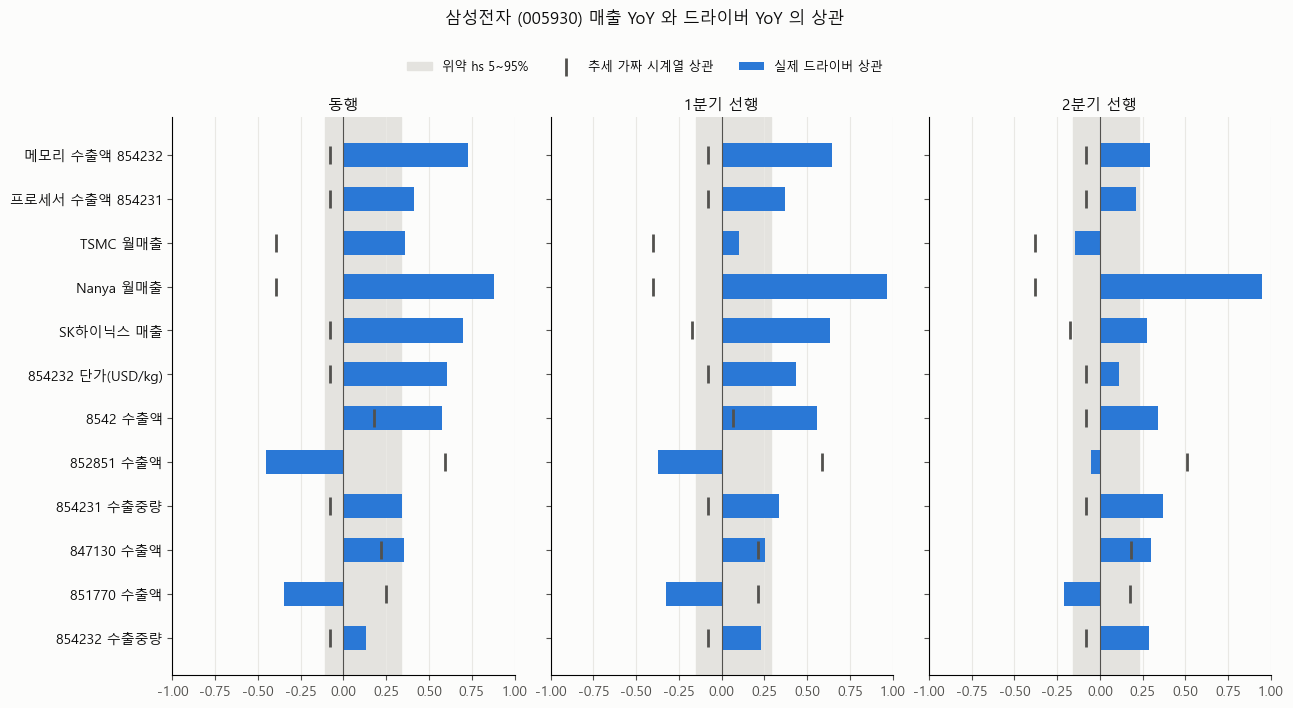

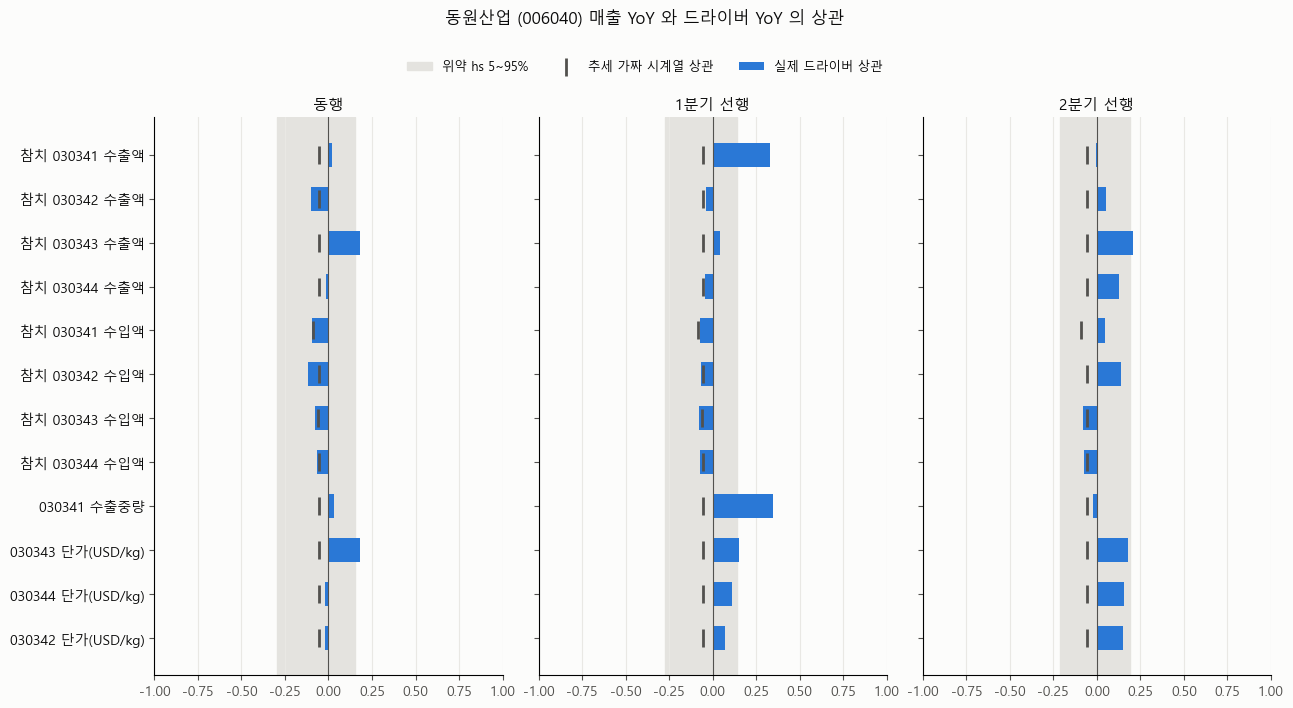

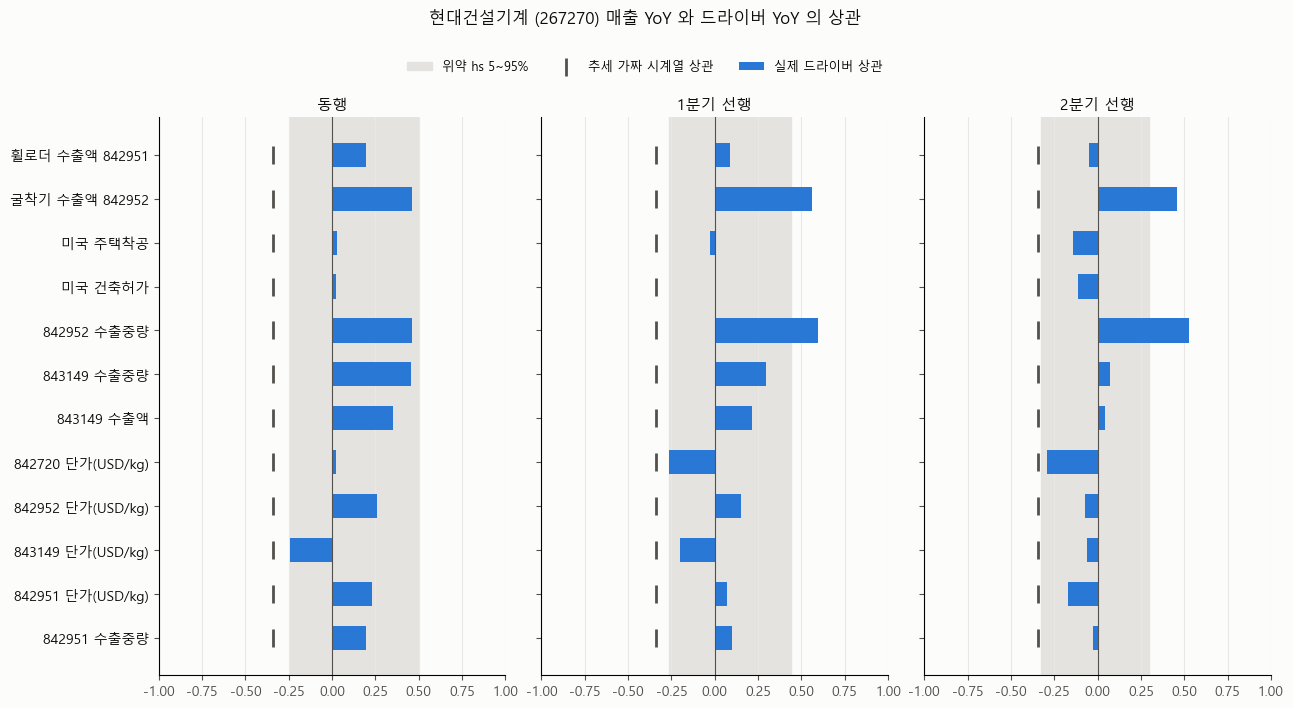

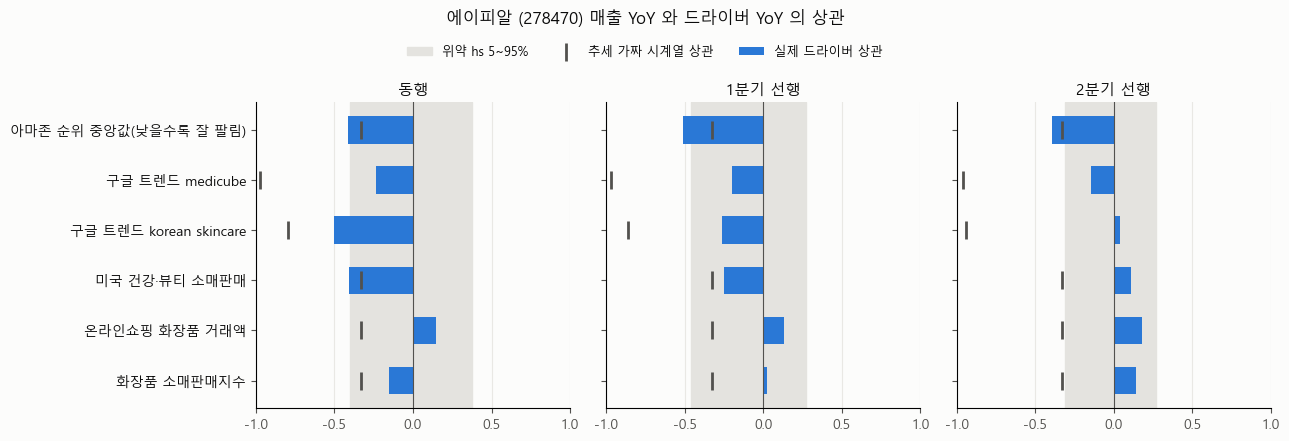

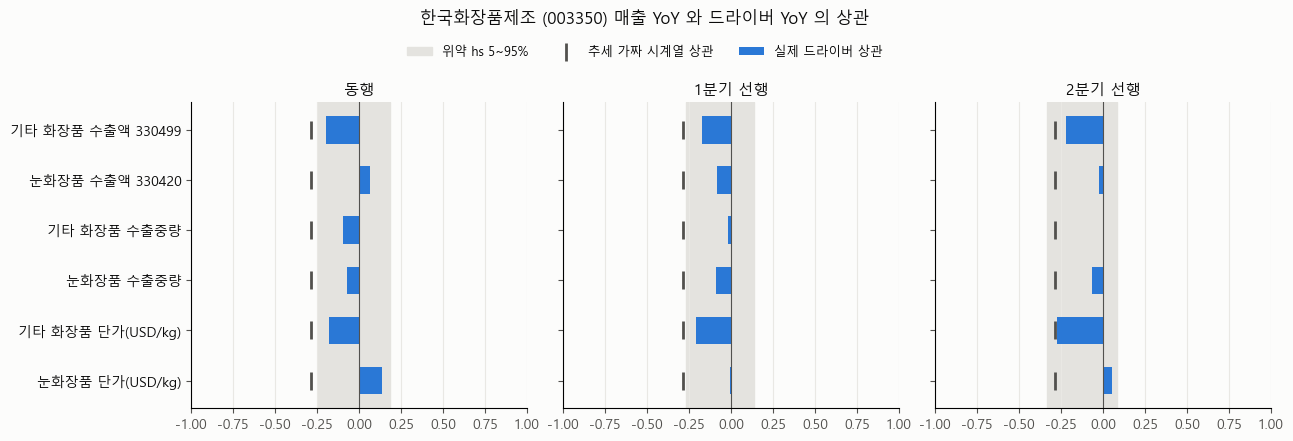

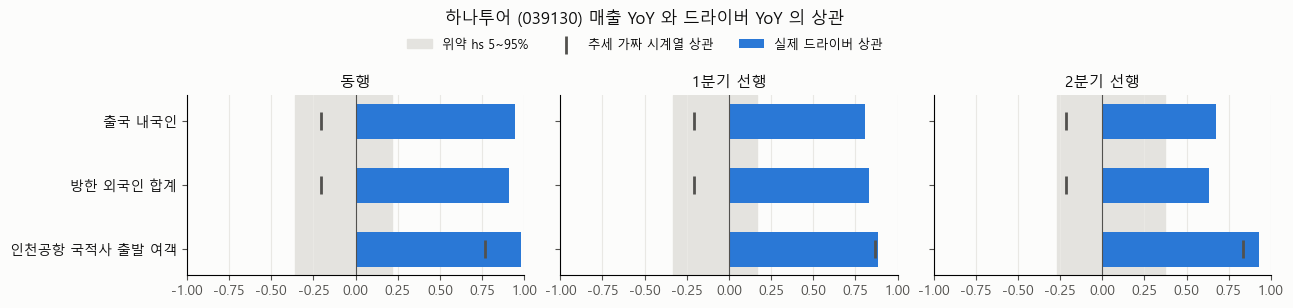

In [10]:
LABEL = {
    "trade:854232:expDlr": "메모리 수출액 854232", "trade:854231:expDlr": "프로세서 수출액 854231",
    "tw_revenue:2330": "TSMC 월매출", "tw_revenue:2408": "Nanya 월매출", "kr_peer:000660:revenue": "SK하이닉스 매출",
    "trade:842951:expDlr": "휠로더 수출액 842951", "trade:842952:expDlr": "굴착기 수출액 842952",
    "fred:HOUST": "미국 주택착공", "fred:PERMIT": "미국 건축허가",
    "amazon_bsr:median_rank": "아마존 순위 중앙값(낮을수록 잘 팔림)", "google_trends:US:medicube": "구글 트렌드 medicube",
    "google_trends:US:korean skincare": "구글 트렌드 korean skincare", "fred:RSHPCS": "미국 건강·뷰티 소매판매",
    "kosis:kosis_113bb45a04e152ed": "온라인쇼핑 화장품 거래액", "kosis:kosis_b85f8425a11ca86a": "화장품 소매판매지수",
    "trade:330499:expDlr": "기타 화장품 수출액 330499", "trade:330420:expDlr": "눈화장품 수출액 330420",
    "trade:330499:expWgt": "기타 화장품 수출중량", "trade:330420:expWgt": "눈화장품 수출중량",
    "trade:330499:unit_price": "기타 화장품 단가(USD/kg)", "trade:330420:unit_price": "눈화장품 단가(USD/kg)",
    "tourism:D:100": "출국 내국인", "tourism:E:TOTAL": "방한 외국인 합계", "airline:intl_dep_sum": "인천공항 국적사 출발 여객",
}
for c in ["030341", "030342", "030343", "030344"]:
    LABEL[f"trade:{c}:expDlr"] = f"참치 {c} 수출액"; LABEL[f"trade:{c}:impDlr"] = f"참치 {c} 수입액"
ITEM_KOR = {"expDlr": "수출액", "expWgt": "수출중량", "impDlr": "수입액", "unit_price": "단가(USD/kg)"}
def lab(d):
    if d in LABEL:
        return LABEL[d]
    parts = d.split(":")
    if parts[0] == "trade" and len(parts) == 3:
        return f"{parts[1]} {ITEM_KOR.get(parts[2], parts[2])}"
    return d

def lag_figure(eid, res, max_rows=12, title_suffix=""):
    spec = [d for d in pa.SPEC_DRIVERS[eid] if d in set(res["driver"])]
    others = (res[~res["driver"].isin(spec)].assign(a=lambda d: d["corr"].abs())
              .groupby("driver")["a"].max().sort_values(ascending=False).index.tolist())
    drivers = (spec + others)[:max_rows]
    fig, axes = plt.subplots(1, 3, figsize=(13, 0.42 * len(drivers) + 1.6), sharey=True, facecolor=SURFACE)
    for ax, k in zip(axes, pa.LAGS):
        r = res[res["lag"] == k].set_index("driver").reindex(drivers)
        y = np.arange(len(drivers))
        p05, p95 = r["placebo_p05"].dropna(), r["placebo_p95"].dropna()
        if len(p05):
            ax.axvspan(p05.iloc[0], p95.iloc[0], color=BAND, zorder=0, label="위약 hs 5~95%")
        ax.barh(y, r["corr"], height=0.55, color=BLUE, zorder=2, label="실제 드라이버 상관")
        ax.scatter(r["trend_corr"], y, marker="|", s=160, color=INK2, linewidths=2, zorder=3, label="추세 가짜 시계열 상관")
        ax.axvline(0, color=INK2, linewidth=0.8)
        ax.set_xlim(-1, 1); ax.set_facecolor(SURFACE)
        ax.set_title(["동행", "1분기 선행", "2분기 선행"][k], color=INK, fontsize=11)
        ax.grid(axis="x", color=GRID, linewidth=0.8); ax.set_axisbelow(True)
        for s in ("top", "right"): ax.spines[s].set_visible(False)
        ax.tick_params(colors=INK2)
    axes[0].set_yticks(np.arange(len(drivers))); axes[0].set_yticklabels([lab(d) for d in drivers], color=INK)
    axes[0].invert_yaxis()
    h, l = axes[0].get_legend_handles_labels()
    fig.legend(h, l, loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.0), fontsize=9)
    fig.suptitle(f"{PILOTS[eid]} ({eid}) 매출 YoY 와 드라이버 YoY 의 상관{title_suffix}", y=1.06, color=INK, fontsize=12)
    fig.tight_layout()
    return fig

for eid in PILOTS:
    fig = lag_figure(eid, results[eid])
    fig.savefig(FIG_DIR / f"corr_lags_{eid}.png", dpi=130, bbox_inches="tight", facecolor=SURFACE)
    plt.show()

### 그림: 매출 YoY 와 가장 뚜렷한 후보 드라이버 YoY (드라이버는 선행 분기만큼 뒤로 밀어 겹침)

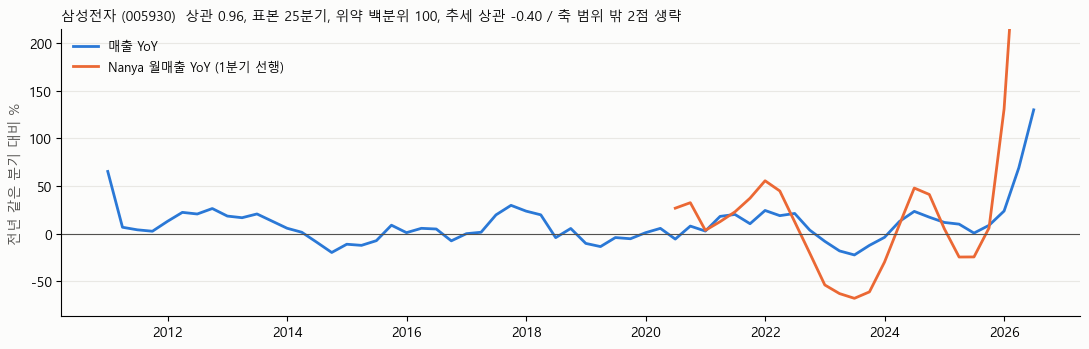

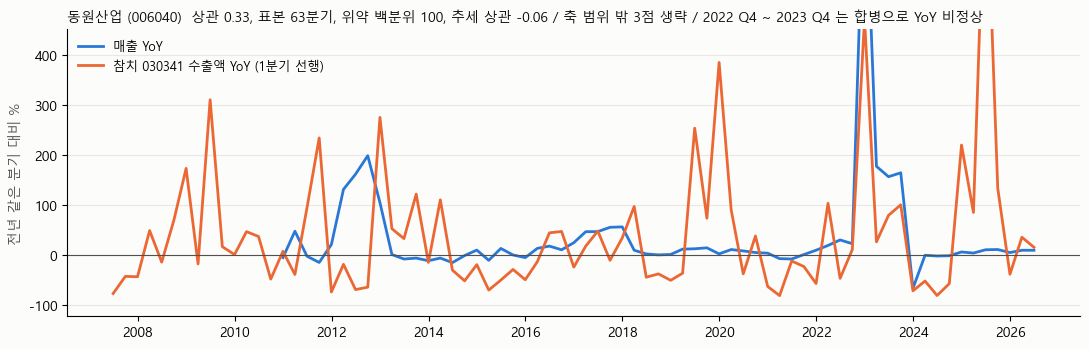

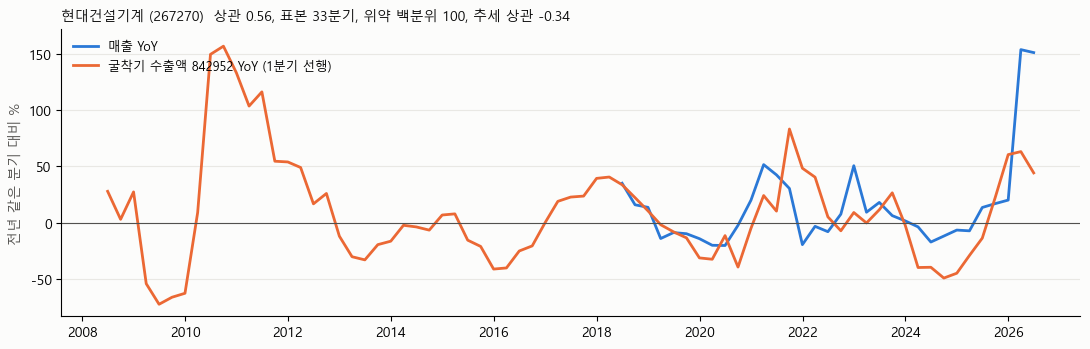

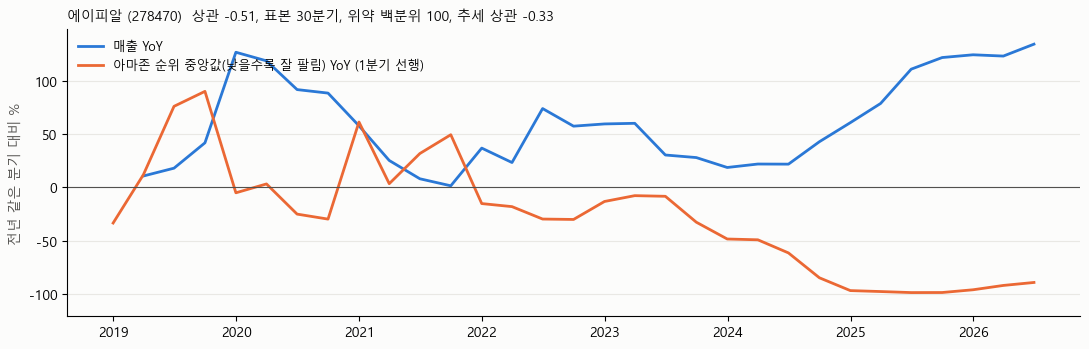

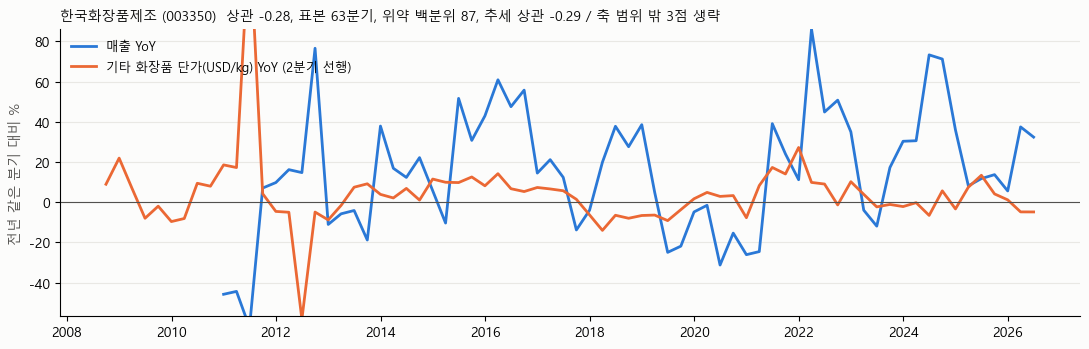

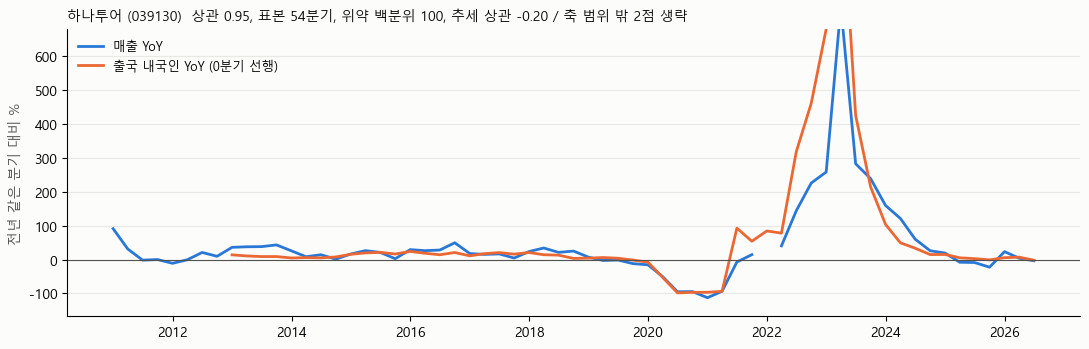

In [11]:
def line_figure(eid, mask_note=None):
    r = results[eid]; yy = yoys[eid]
    cand = r[r["driver"].isin(pa.SPEC_DRIVERS[eid])].dropna(subset=["corr"])
    # 판정이 뚜렷한 것, 표본 20분기 이상인 것을 먼저, 그다음 위약 백분위와 |상관| 순
    cand = cand.assign(a=cand["corr"].abs(), clear=(cand["verdict"] == "뚜렷"), big=(cand["n"] >= 20))
    cand = cand.sort_values(["clear", "big", "placebo_pct_abs", "a"], ascending=False)
    top = cand.iloc[0]
    d, k = top["driver"], int(top["lag"])
    x = (yy[d].shift(k) * 100); y = yy["revenue"] * 100
    fig, ax = plt.subplots(figsize=(11, 3.6), facecolor=SURFACE)
    ax.plot(y.index, y, color=BLUE, linewidth=2, label="매출 YoY")
    ax.plot(x.index, x, color=ORANGE, linewidth=2, label=f"{lab(d)} YoY ({k}분기 선행)")
    both = pd.concat([x, y]).dropna()
    lo, hi = np.nanpercentile(both, 2), np.nanpercentile(both, 98)
    pad = (hi - lo) * 0.1
    ax.set_ylim(lo - pad, hi + pad)
    clipped = int(((both < lo - pad) | (both > hi + pad)).sum())
    ax.axhline(0, color=INK2, linewidth=0.8)
    ax.set_ylabel("전년 같은 분기 대비 %", color=INK2); ax.set_facecolor(SURFACE)
    ax.grid(axis="y", color=GRID); ax.set_axisbelow(True)
    for s in ("top", "right"): ax.spines[s].set_visible(False)
    ax.legend(frameon=False, loc="upper left", fontsize=9)
    note = f"상관 {top['corr']:.2f}, 표본 {int(top['n'])}분기, 위약 백분위 {top['placebo_pct_abs']:.0f}, 추세 상관 {top['trend_corr']:.2f}"
    if clipped:
        note += f" / 축 범위 밖 {clipped}점 생략"
    if mask_note:
        note += f" / {mask_note}"
    ax.set_title(f"{PILOTS[eid]} ({eid})  {note}", color=INK, fontsize=10, loc="left")
    fig.tight_layout()
    return fig

for eid in PILOTS:
    note = "2022 Q4 ~ 2023 Q4 는 합병으로 YoY 비정상" if eid == "006040" else None
    fig = line_figure(eid, note)
    fig.savefig(FIG_DIR / f"yoy_line_{eid}.png", dpi=130, bbox_inches="tight", facecolor=SURFACE)
    plt.show()

## 5. 동원산업: 2022년 합병 전후 분리

2022 Q4 매출 단독값은 `사업보고서 연간(합병 후 기준) - 1~3분기(합병 전 기준)` 이라 6.45조로 튄다 (합병 전 분기는 0.7~0.9조, 합병 후 2.1~2.4조).
그래서 YoY 를 세 구간으로 본다.
- 전체: 합병 영향을 받은 2022 Q4 ~ 2023 Q4 YoY 포함 (참고용)
- 합병 전: YoY 기준 분기와 비교 분기가 모두 합병 전 (~ 2022 Q3)
- 합병 후: 둘 다 합병 후 (2024 Q1 ~)

In [12]:
eid = "006040"; yy = yoys[eid]
display(wides[eid].loc["2021-12-31":"2024-06-30", ["revenue"]].assign(조원=lambda d: (d["revenue"] / 1e12).round(2)))
idx = yy.index
masks = {"전체(합병 영향 포함)": pd.Series(True, index=idx),
         "합병 전 (~2022 Q3)": pd.Series(idx <= pa.DONGWON_PRE_END, index=idx),
         "합병 후 (2024 Q1~)": pd.Series(idx >= pa.DONGWON_POST_START, index=idx)}
codes = pa.placebo_codes(eid, pool)
dw = []
for name, m in masks.items():
    plc = pa.placebo_corrs(codes, yy["revenue"], 12, mask=m)
    ct = pa.corr_table(yy, pa.SPEC_DRIVERS[eid], mask=m)
    dw.append(pa.judge(ct, plc).assign(구간=name))
dongwon = pd.concat(dw, ignore_index=True)
dongwon.to_csv(OUT_DIR / "dongwon_merger_split.csv", index=False, encoding="utf-8-sig")
piv = dongwon.pivot_table(index=["driver", "lag"], columns="구간", values="corr").round(3)
piv_n = dongwon.pivot_table(index=["driver", "lag"], columns="구간", values="n")
display(Markdown("**상관 (구간별)**")); display(piv.rename(index=lab, level=0))
display(Markdown("**표본 분기 수**")); display(piv_n.iloc[:1])
display(Markdown("**판정 (구간별)**"))
display(dongwon.pivot_table(index=["driver", "lag"], columns="구간", values="verdict", aggfunc="first").rename(index=lab, level=0))

driver,revenue,조원
period_end,,
2021-12-31,7.178367e+11,0.72
2022-03-31,8.159915e+11,0.82
2022-06-30,8.563004e+11,0.86
2022-09-30,9.011965e+11,0.90
2022-12-31,6.452770e+12,6.45
2023-03-31,2.264232e+12,2.26
2023-06-30,2.197763e+12,2.20
2023-09-30,2.384255e+12,2.38
2023-12-31,2.102321e+12,2.10


**상관 (구간별)**

구간                 전체(합병 영향 포함)  합병 전 (~2022 Q3)  합병 후 (2024 Q1~)
driver        lag                                                
참치 030341 수출액 0           0.022            0.172           -0.078
              1           0.330           -0.079            0.556
              2          -0.004           -0.205            0.501
참치 030341 수입액 0          -0.097           -0.160           -0.953
              1          -0.075           -0.083           -0.445
              2           0.046            0.021           -0.149
참치 030342 수출액 0          -0.100            0.349            0.344
              1          -0.039            0.261            0.063
              2           0.054            0.076           -0.401
참치 030342 수입액 0          -0.118            0.026            0.588
              1          -0.067            0.128            0.340
              2           0.141            0.171            0.465
참치 030343 수출액 0           0.181            0.374           -0.556
              1           0.041           -0.015           -0.633
              2           0.209            0.028           -0.592
참치 030343 수입액 0          -0.079           -0.059           -0.273
              1          -0.078           -0.038           -0.355
              2          -0.078           -0.050           -0.403
참치 030344 수출액 0          -0.014           -0.123            0.545
              1          -0.045           -0.100            0.009
              2           0.125            0.057           -0.458
참치 030344 수입액 0          -0.069            0.097            0.405
              1          -0.071            0.067            0.267
              2          -0.075            0.034            0.604

**표본 분기 수**

,구간,전체(합병 영향 포함),합병 전 (~2022 Q3),합병 후 (2024 Q1~)
driver,lag,,,
trade:030341:expDlr,0,63.0,48.0,10.0


**판정 (구간별)**

구간                전체(합병 영향 포함) 합병 전 (~2022 Q3) 합병 후 (2024 Q1~)
driver        lag                                             
참치 030341 수출액 0     위약과 구분 안 됨      위약과 구분 안 됨      위약과 구분 안 됨
              1             뚜렷      위약과 구분 안 됨      위약과 구분 안 됨
              2     위약과 구분 안 됨      위약과 구분 안 됨      위약과 구분 안 됨
참치 030341 수입액 0     위약과 구분 안 됨      위약과 구분 안 됨           표본 부족
              1     위약과 구분 안 됨      위약과 구분 안 됨           표본 부족
              2     위약과 구분 안 됨      위약과 구분 안 됨           표본 부족
참치 030342 수출액 0     위약과 구분 안 됨              뚜렷      위약과 구분 안 됨
              1     위약과 구분 안 됨      위약과 구분 안 됨      위약과 구분 안 됨
              2     위약과 구분 안 됨      위약과 구분 안 됨      위약과 구분 안 됨
참치 030342 수입액 0     위약과 구분 안 됨      위약과 구분 안 됨      위약과 구분 안 됨
              1     위약과 구분 안 됨      위약과 구분 안 됨      위약과 구분 안 됨
              2     위약과 구분 안 됨      위약과 구분 안 됨      위약과 구분 안 됨
참치 030343 수출액 0     위약과 구분 안 됨              뚜렷      위약과 구분 안 됨
              1     위약과 구분 안 됨      위약과 구분 안 됨      위약과 구분 안 됨
              2     위약과 구분 안 됨      위약과 구분 안 됨      위약과 구분 안 됨
참치 030343 수입액 0     위약과 구분 안 됨      위약과 구분 안 됨      위약과 구분 안 됨
              1     위약과 구분 안 됨      위약과 구분 안 됨      위약과 구분 안 됨
              2     위약과 구분 안 됨      위약과 구분 안 됨      위약과 구분 안 됨
참치 030344 수출액 0     위약과 구분 안 됨      위약과 구분 안 됨      위약과 구분 안 됨
              1     위약과 구분 안 됨      위약과 구분 안 됨      위약과 구분 안 됨
              2     위약과 구분 안 됨      위약과 구분 안 됨      위약과 구분 안 됨
참치 030344 수입액 0     위약과 구분 안 됨      위약과 구분 안 됨      위약과 구분 안 됨
              1     위약과 구분 안 됨      위약과 구분 안 됨      위약과 구분 안 됨
              2     위약과 구분 안 됨      위약과 구분 안 됨      위약과 구분 안 됨

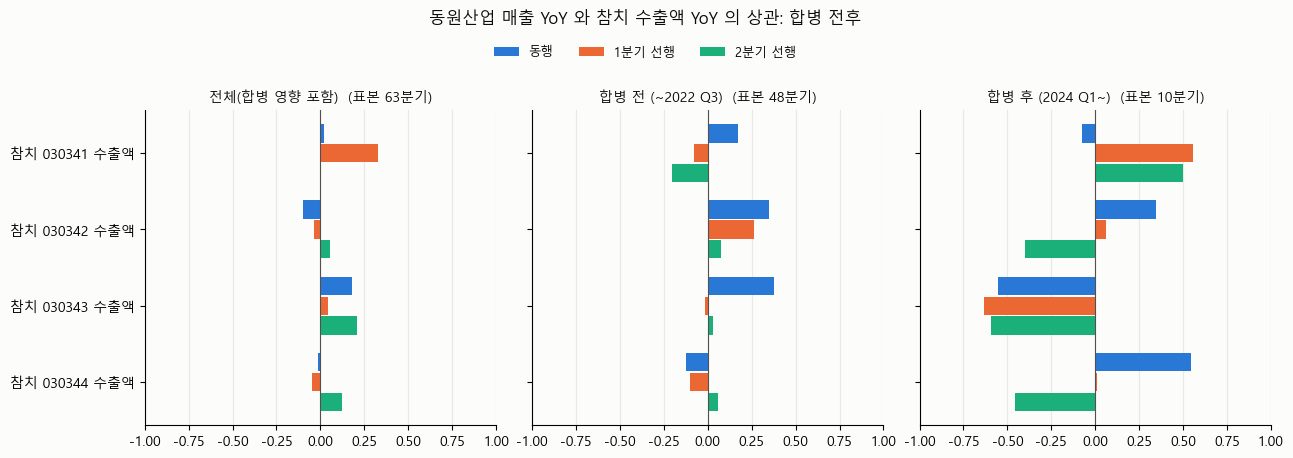

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharey=True, facecolor=SURFACE)
drv = [d for d in pa.SPEC_DRIVERS[eid] if d.endswith("expDlr")]
for ax, (name, m) in zip(axes, masks.items()):
    sub = dongwon[(dongwon["구간"] == name) & dongwon["driver"].isin(drv)]
    y = np.arange(len(drv))
    for j, (k, col) in enumerate(zip(pa.LAGS, [BLUE, ORANGE, AQUA])):
        r = sub[sub["lag"] == k].set_index("driver").reindex(drv)
        ax.barh(y + (j - 1) * 0.26, r["corr"], height=0.24, color=col, label=["동행", "1분기 선행", "2분기 선행"][k])
    ax.axvline(0, color=INK2, linewidth=0.8); ax.set_xlim(-1, 1); ax.set_facecolor(SURFACE)
    n = int(sub["n"].max()) if len(sub) else 0
    ax.set_title(f"{name}  (표본 {n}분기)", color=INK, fontsize=10)
    ax.grid(axis="x", color=GRID); ax.set_axisbelow(True)
    for s in ("top", "right"): ax.spines[s].set_visible(False)
axes[0].set_yticks(np.arange(len(drv))); axes[0].set_yticklabels([lab(d) for d in drv]); axes[0].invert_yaxis()
h, l = axes[0].get_legend_handles_labels()
fig.legend(h, l, loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.02), fontsize=9)
fig.suptitle("동원산업 매출 YoY 와 참치 수출액 YoY 의 상관: 합병 전후", y=1.08, color=INK)
fig.tight_layout()
fig.savefig(FIG_DIR / "dongwon_merger_split.png", dpi=130, bbox_inches="tight", facecolor=SURFACE)
plt.show()

## 6. 추가 점검

### 6.1 하나투어: 코로나 구간(2020~2023) 제외
2020~2022 급감과 2023 회복이 상관을 키웠을 수 있어, 그 구간을 뺀 상관도 본다. (YoY 기준 2020 Q1 ~ 2023 Q4 제외)

In [14]:
eid = "039130"; yy = yoys[eid]; idx = yy.index
m = pd.Series((idx < "2020-03-31") | (idx > "2023-12-31"), index=idx)
plc = pa.placebo_corrs(pa.placebo_codes(eid, pool), yy["revenue"], 12, mask=m)
hana_ex = pa.judge(pa.corr_table(yy, pa.SPEC_DRIVERS[eid], mask=m), plc)
hana_ex.to_csv(OUT_DIR / "hanatour_ex_covid.csv", index=False, encoding="utf-8-sig")
show(hana_ex)

,드라이버,선행(분기),상관,표본,위약 백분위,위약 5%,위약 95%,추세 상관,판정,시작,끝
0,tourism:D:100,0,0.811,39,100.000,-0.297,0.259,0.153,뚜렷,2012-12-31,2026-06-30
1,tourism:D:100,1,0.807,38,100.000,-0.198,0.430,0.130,뚜렷,2013-03-31,2026-06-30
2,tourism:D:100,2,0.795,37,100.000,-0.281,0.281,0.102,뚜렷,2013-06-30,2026-06-30
3,tourism:E:TOTAL,0,0.531,39,100.000,-0.297,0.259,0.153,뚜렷,2012-12-31,2026-06-30
4,tourism:E:TOTAL,1,0.487,38,93.333,-0.198,0.430,0.130,뚜렷,2013-03-31,2026-06-30
5,tourism:E:TOTAL,2,0.570,37,100.000,-0.281,0.281,0.102,뚜렷,2013-06-30,2026-06-30
6,airline:intl_dep_sum,0,0.916,10,100.000,-0.297,0.259,0.727,뚜렷,2024-03-31,2026-06-30
7,airline:intl_dep_sum,1,0.930,10,100.000,-0.198,0.430,0.727,뚜렷,2024-03-31,2026-06-30
8,airline:intl_dep_sum,2,0.942,10,100.000,-0.281,0.281,0.727,뚜렷,2024-03-31,2026-06-30


### 6.2 수준 상관과 추세 (왜 YoY 로 보는가)
매출이 꾸준히 늘면, 같이 늘기만 하는 시계열은 무엇이든 수준 상관이 높게 나온다. 추세 가짜 시계열(100 + t)의 수준 상관이 그 기준선이다.

In [15]:
lv = pd.concat([pa.level_vs_trend(wides[e], pa.SPEC_DRIVERS[e]).assign(기업=PILOTS[e]) for e in PILOTS], ignore_index=True)
lv["드라이버"] = lv["driver"].map(lab)
lv.to_csv(OUT_DIR / "level_vs_trend.csv", index=False, encoding="utf-8-sig")
display(lv[["기업", "드라이버", "level_corr", "trend_level_corr", "n"]]
        .rename(columns={"level_corr": "수준 상관", "trend_level_corr": "추세 가짜 시계열 수준 상관", "n": "표본"}).round(3))

,기업,드라이버,수준 상관,추세 가짜 시계열 수준 상관,표본
0,삼성전자,메모리 수출액 854232,0.932,0.756,67
1,삼성전자,프로세서 수출액 854231,0.783,0.756,67
2,삼성전자,TSMC 월매출,0.818,0.676,30
3,삼성전자,Nanya 월매출,0.884,0.676,30
4,삼성전자,SK하이닉스 매출,0.942,0.756,67
5,동원산업,참치 030341 수출액,-0.067,0.723,67
6,동원산업,참치 030342 수출액,-0.357,0.723,67
7,동원산업,참치 030343 수출액,-0.149,0.723,67
8,동원산업,참치 030344 수출액,-0.376,0.723,67
9,동원산업,참치 030341 수입액,-0.067,0.723,67


## 7. 명세서 6절 성공 기준 점검

In [16]:
crit = []
ok1 = all((p["driver"] == "revenue").any() and p["driver"].nunique() >= 2 for p in panels.values())
crit.append(("6개 기업 모두 panel() 한 줄로 매출과 연결 시계열이 분기 단위 한 표로 나온다", ok1,
             ", ".join(f"{PILOTS[e]} {p['driver'].nunique()}개" for e, p in panels.items())))
ok2 = (panel_summary["available_at 빈 값"].sum() == 0) and (panel_summary["등급 빈 값"].sum() == 0)
crit.append(("모든 값에 available_at 과 asof_quality 가 붙어 있고, 등급별 비율이 기업마다 보고된다", ok2,
             "2절 panel_summary, panel_driver_summary"))
ok3 = asof_check["미래 값"].sum() == 0 and len(asof_check) == 60
crit.append(("as_of(panel, 날짜) 가 그 날짜 이후 발표된 값을 하나도 포함하지 않는다 (자동 테스트)", ok3,
             f"6개 기업 x 날짜 10개 = {len(asof_check)}건, 미래 값 {asof_check['미래 값'].sum()}건 (+ tests/test_panel_bulk.py)"))
n_fig = len(list(FIG_DIR.glob("corr_lags_*.png"))) + len(list(FIG_DIR.glob("yoy_line_*.png")))
ok4 = set(all_res["entity"]) == set(PILOTS) and set(all_res["lag"]) == {0, 1, 2} and n_fig >= 12
crit.append(("기업별 매출 YoY 와 후보 드라이버 YoY 상관(동행, 1·2분기 선행)을 표와 그림으로 출력한다", ok4,
             f"표 corr_placebo_all.csv ({len(all_res)}행), 그림 {n_fig}개 + 위약 검정"))
ok5 = len(db.WRITE_LOG) == WRITES_AT_START
crit.append(("원본 테이블 쓰기 0건", ok5,
             f"이 노트북 실행 중 쓰기 {len(db.WRITE_LOG) - WRITES_AT_START}건 (읽기 전용 세션). entity 재적재 쓰기는 fd_ 2개 테이블만 (세션 리포트 참조)"))
criteria = pd.DataFrame(crit, columns=["성공 기준", "충족", "근거"])
criteria["충족"] = criteria["충족"].map({True: "충족", False: "미충족"})
criteria.to_csv(OUT_DIR / "success_criteria.csv", index=False, encoding="utf-8-sig")
display(criteria)

,성공 기준,충족,근거
0,6개 기업 모두 panel() 한 줄로 매출과 연결 시계열이 분기 단위 한 표로 나온다,충족,"삼성전자 32개, 동원산업 17개, 현대건설기계 15개, 에이피알 7개, 한국화장품..."
1,"모든 값에 available_at 과 asof_quality 가 붙어 있고, 등급별...",충족,"2절 panel_summary, panel_driver_summary"
2,"as_of(panel, 날짜) 가 그 날짜 이후 발표된 값을 하나도 포함하지 않는다...",충족,"6개 기업 x 날짜 10개 = 60건, 미래 값 0건 (+ tests/test_pa..."
3,"기업별 매출 YoY 와 후보 드라이버 YoY 상관(동행, 1·2분기 선행)을 표와 ...",충족,"표 corr_placebo_all.csv (228행), 그림 12개 + 위약 검정"
4,원본 테이블 쓰기 0건,충족,이 노트북 실행 중 쓰기 0건 (읽기 전용 세션). entity 재적재 쓰기는 fd...
